# **Sentiment Analysis | Naive Bayes**

Model prediksi kelompok komentar pengguna menggunakan algoritma Naive Bayes.

## 1. Data Understanding 

### 1.1 Import Library

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import tkinter as tk 
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download('stopwords')
from nltk.corpus import stopwords as nltk_stopwords
from tkinter import messagebox

[nltk_data] Downloading package stopwords to /home/akyrr/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 1.2 Read Dataset

In [25]:
# Importing dataset 
try:
    sentiment = pd.read_csv('dataset_penyisihan_bdc_2024.csv', sep=';')
    print('Dataset complacated.')
except ValueError as e:
    print(f'\nError: {e}')


Dataset complacated.


In [26]:
# Show the 5 top rows of dataset
print('\n5 top rows of dataset:')
sentiment.head()


5 top rows of dataset:


,text,label
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik


In [27]:
# Show the information of dataset
print('\nInformation of dataset:')
sentiment.info()


Information of dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5000 non-null   str  
 1   label   5000 non-null   str  
dtypes: str(2)
memory usage: 78.3 KB


In [28]:
# show the diimensional data
print('\nDimensional data:')
print('Number of rows:', sentiment.shape[0])
print('Number of columns:', sentiment.shape[1])


Dimensional data:
Number of rows: 5000
Number of columns: 2


In [29]:
# Show the number of missing values and duplicated data 
print('\nNumber of missing values:', sentiment.isnull().sum().sum())
print('\nNumber of duplcated data:', sentiment.duplicated().sum())


Number of missing values: 0

Number of duplcated data: 381


In [30]:
# Show the rows that have a duplicated data
print('\nRows that have a duplicated data:')
sentiment[sentiment.duplicated(keep=False)]


Rows that have a duplicated data:


,text,label
17,RT Trending On Twitter ( X) Anies Bubble merok...,Sosial Budaya
20,RT Abah Anies ingin mengangkat martabat petani...,Sosial Budaya
38,"RT Anak Muda Indonesia, the future of this nat...",Ideologi
40,"RT According to Prabowo, Gaza is opressed beca...",Pertahanan dan Keamanan
41,"RT Ini kejam, warga disitu sudah bersedia diba...",Sosial Budaya
...,...,...
4917,"RT Ini kejam, warga disitu sudah bersedia diba...",Sosial Budaya
4933,RT Karena program pak anies yg ini. Bapak gw j...,Sumber Daya Alam
4955,RT Ekonom: Program Makan Siang dan Susu Gratis...,Ekonomi
4971,"RT menjelang tengah malam ini, aku mau ucapkan...",Ideologi


In [31]:
# Show the number of unique vaulues
print('\nNumber of unique values per columns:')
sentiment.nunique()


Number of unique values per columns:


text     4583
label       8
dtype: int64

In [32]:
# Show the unique values of label
print('\nUnique values of target:')
sentiment['label'].unique().tolist()


Unique values of target:


['Sumber Daya Alam',
 'Politik',
 'Demografi',
 'Pertahanan dan Keamanan',
 'Ideologi',
 'Ekonomi',
 'Sosial Budaya',
 'Geografi']

#### **Conclution of Data Understanding** 

1. Dataset memiliki 5000 baris data dengan  2 kolom.
2. Dari 5000 baris data, terdapat 4583 nilai unik. Itu artinya, ada total 38 nilai duplikat yang harus ditangani.
3. Tidak terdapat missing value pada dataset ini. 
4. Terdapat 8 jenis/kelompok komentar pada dataset ini.

## 2. Exploratory Data Analysis 

### 2.1 Multivariate Analysis 

#### Statistical Analysis

In [33]:
# Show the statistical summary analysis 
print('\nStatistical summary:')
sentiment.describe()


Statistical summary:


,text,label
count,5000,5000
unique,4583,8
top,RT Abah Anies ingin mengangkat martabat petani...,Politik
freq,42,2972


In [34]:
# Number of duplicated data 
print('Number of duplicated data:', sentiment.duplicated().sum())
dup = 5000 - 4538 
print('Number of sentiment that have a same comment:', dup)

different_label = dup - 381
print('Number of sentiment that have a same comment but have not the same label:', different_label)

Number of duplicated data: 381
Number of sentiment that have a same comment: 462
Number of sentiment that have a same comment but have not the same label: 81


- Insight:
1. Ada 81 komen yang sama dengan label yang berbeda. ini bisa membingungkan model.
2. Komentar terbanyak adalah komentar tentang politik dengan jumlah 2.972 komentar. 
3. Komentar 'RT Abah Anies ingin mengangakat...' memiliki jumlah 42 komentar. 

- Solusi:
1. Penanganan data duplikat dengan dihapus. 


In [35]:
# Lenght of text 
sentiment['text_len'] = sentiment['text'].apply(len)

# Lenght word per text
sentiment['word_len'] = sentiment['text'].apply(lambda x: len(str(x).split()))

# Encoding label using mapping technique
sentiment['label_num'] = sentiment['label'].map({
    'Sumber Daya Alam': 0,
    'Politik': 1,
    'Demografi': 2,
    'Pertahanan dan Keamanan': 3,
    'Ideologi': 4,
    'Ekonomi': 5,
    'Sosial Budaya': 6,
    'Geografi': 7,
})

In [36]:
# Separate the catecorial and numerical columns
num_cols = sentiment.select_dtypes(include=['int64', 'float64'])
cat_cols = sentiment.select_dtypes(include=['object', 'category'])

/tmp/ipykernel_53260/3416071028.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = sentiment.select_dtypes(include=['object', 'category'])


#### Statistical Sumarry for Numerical Columns

In [37]:
# statistical summary for numerical columns
print('\nStatistical Summary for Numerical Columns:')
num_cols.describe()


Statistical Summary for Numerical Columns:


,text_len,word_len,label_num
count,5000.000000,5000.000000,5000.000000
mean,268.815600,32.752800,2.278600
std,314.762818,40.228539,1.926168
min,45.000000,3.000000,0.000000
25%,168.000000,19.000000,1.000000
50%,217.000000,25.000000,1.000000
75%,280.000000,36.000000,4.000000
max,4893.000000,728.000000,7.000000


- Insight:
1. Fitur panjang kata dan huruf, memiliki standart deviation yang cukup besar. Artinya nilai rata-rata mereka cukup jauh dengan nilai maxnya.
2. Nilai median dengan nilai max pada fitur 'text_len' dan 'word_len' memiliki selisih yang cukup jauh. Ada kemungkinan outlier.

- Solusi:
1. Penanganan outlier menggunakan mean, median, modus atau log transform.

#### Correlation Analysis

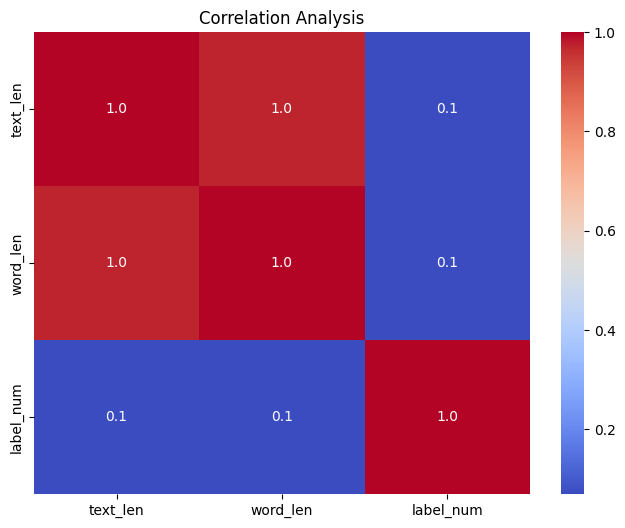

In [38]:
# Show the correlation visualization 
correlation = sentiment[['text_len', 'word_len', 'label_num']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Analysis')
plt.show()

- Insight: 
1. Ternyata, panjang atau pendeknya kalimat atau kata, memiliki korelasi hampir 0.0, yang artinya itu tidak ada hubungan. Panjang pendeknya komentar tertentu, tidak menjamin komentar tersebut masuk kedalam label tertentu.
2. Semakin banyak kata, tentunya semakin banyak kata. 

- Solusi:
1. Saat di permodelan, akan menggukan salah satu dari fitur 'word_len' atau 'text_len' karena memiliki hubungan ynag tinggi.

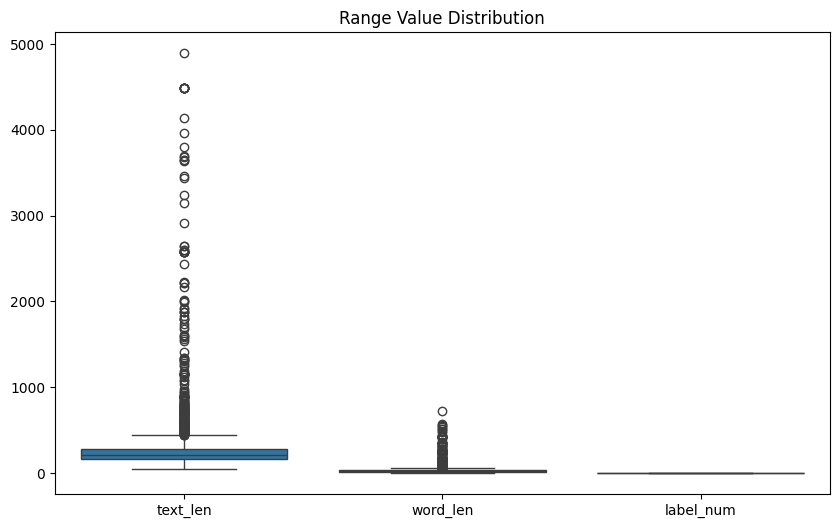

In [39]:
# Shwo boxplot analysis
plt.figure(figsize=(10,6))
sns.boxplot(num_cols)
plt.title('Range Value Distribution')
plt.show()

In [40]:
# Show the number of outliers
num_cols = ['text_len', 'word_len']
results = []

for col in num_cols:
    Q1 = sentiment[col].quantile(0.25)
    Q3 = sentiment[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((sentiment[col] < lower_bound) | (sentiment[col] > upper_bound)).sum()
    
    results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Upper Bound': upper_bound,
        'Outliers Count': outliers_count,
        'Percentage': f"{(outliers_count / len(sentiment) * 100):.2f}%"
    })

iqr_table = pd.DataFrame(results)
print(iqr_table)

    Feature     Q1     Q3    IQR  Upper Bound  Outliers Count Percentage
0  text_len  168.0  280.0  112.0        448.0             278      5.56%
1  word_len   19.0   36.0   17.0         61.5             250      5.00%


- Insight: 
1. Cukup banyak komentar dengan jumlah kata diluar range. 
2. Cukup banyak komentar dengan panjang huruf diluar range/


### 2.2 Univariate Analysis

#### Target Distribution

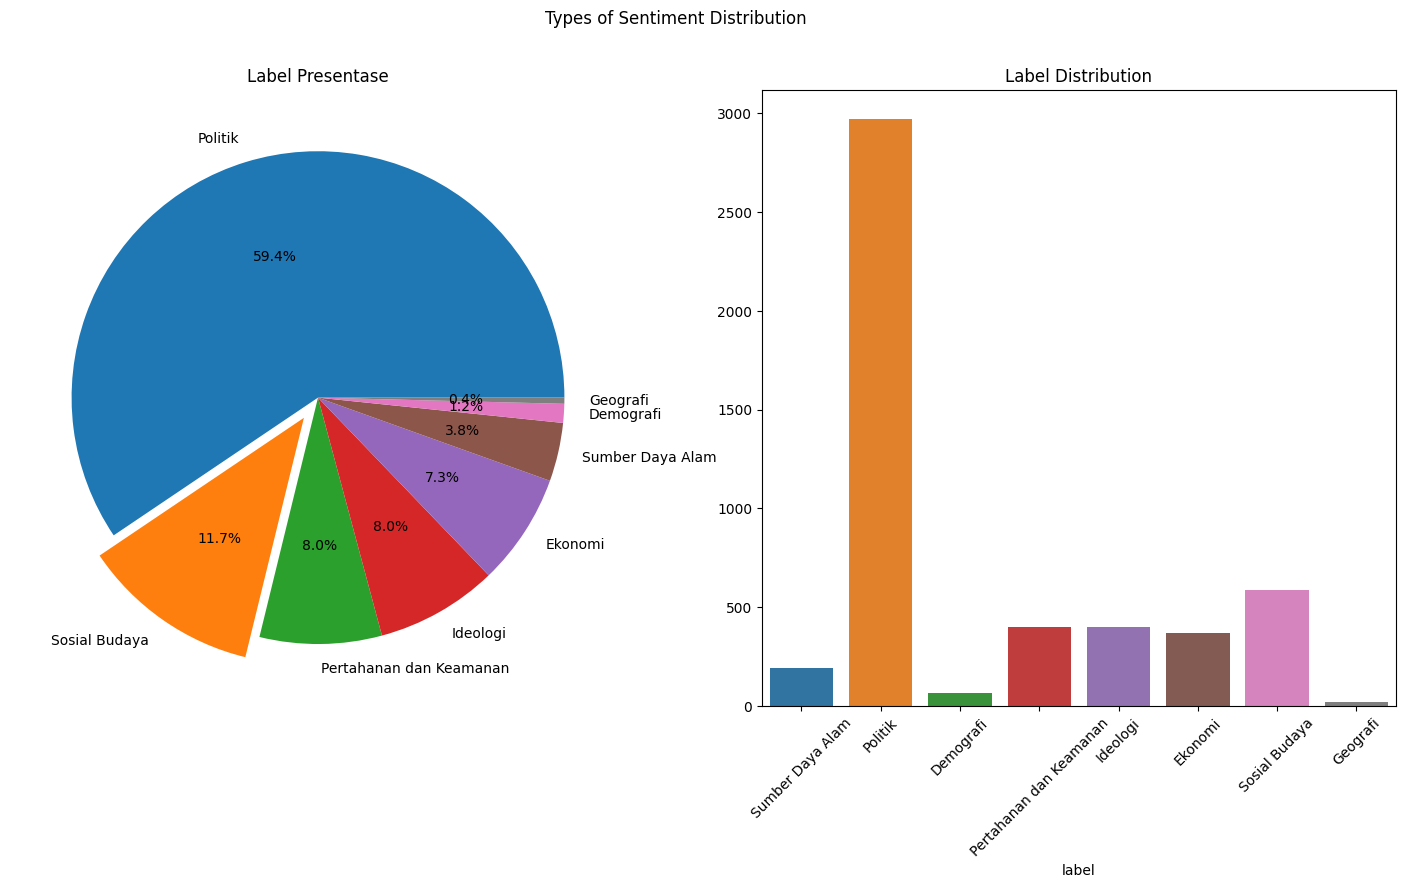

In [41]:
num_labels = sentiment['label'].nunique()
explode_value = [0.1 if i == 1 else 0 for i in range(num_labels)]

f, ax = plt.subplots(1,2, figsize=(18, 8))
sentiment['label'].value_counts().plot.pie(explode=explode_value, autopct='%1.1f%%', ax=ax[0])
ax[0].set_title('Label Presentase')
ax[0].set_ylabel('')

sns.countplot(data=sentiment, x='label', hue='label', ax=ax[1])
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title('Label Distribution')
ax[1].set_ylabel('')

plt.suptitle('Types of Sentiment Distribution')
plt.show()

- Insight: 
1. Target memiliki penyebaran data yang immbalance. Dimana komentar politik mendominasi lebih dari 50%. Sedangkan, target minoritas dengan jumlah paling sedikit adalah komentar Geografi. 

- Solusi:
1. Dilakukan resampling untuk target ini. Karena, model naive bayes sensitif terhadap target immbalance.

#### Feature Distribution

In [42]:
# # Show the distribution per featrue 
# for col in num_cols:
#     plt.figure(figsize=(8, 6))
#     sns.histplot(data=num_cols, x=col, kde=True)
#     plt.title(f'Distribution {col} Feature')
#     plt.show()

- Insight:
1. Penyebaran nilai pada fitur panjang kata dan panjang kata cenderumg miring ke kanan. Dimana, panjang kata komentar cenderung kurang dari 1000, dan panjang huruf kurang dari 100.


### 2.3 Bivariate Analysis

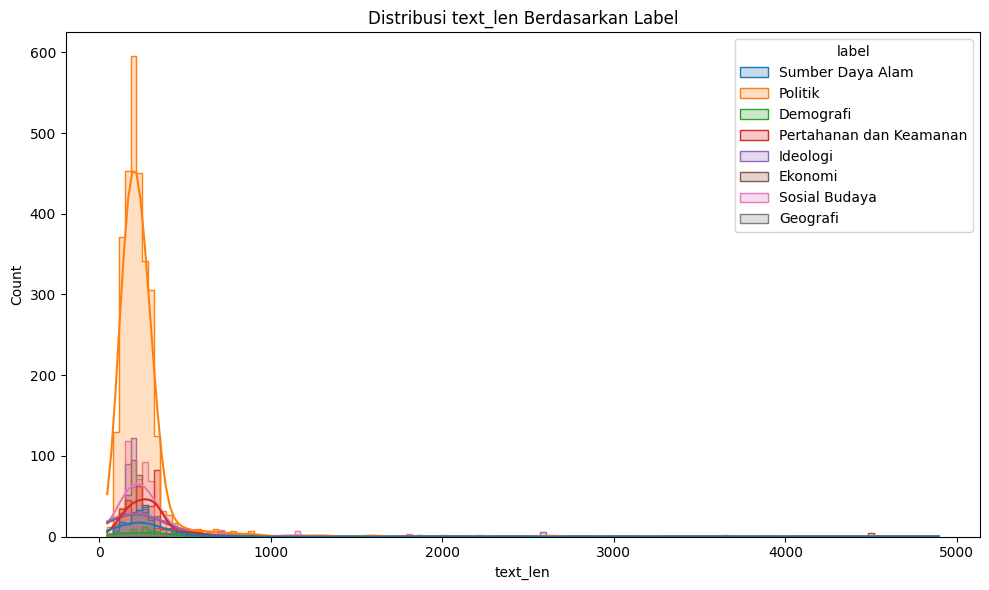

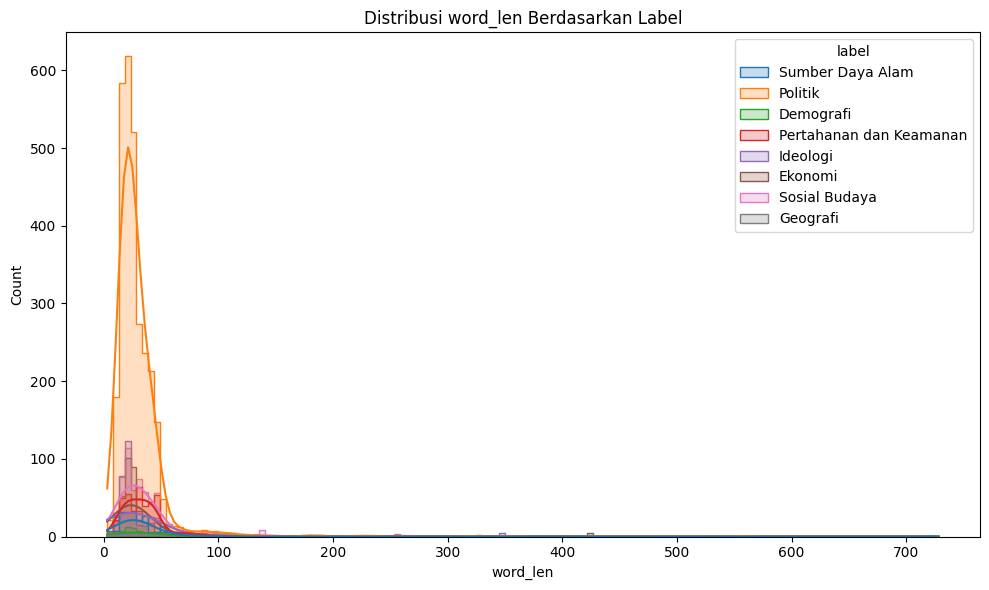

In [43]:
for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=sentiment, x=col, hue='label', element="step", kde=True)
    plt.title(f'Distribusi {col} Berdasarkan Label')
    plt.tight_layout()
    plt.show()

- Insight:
1. Jumlah kata dan huruf dari komentar dataset yang memiliki nilai yang besar, kecenderungan komentar politik.

## 3. Data Preprocessing 

### 3.1 Handling Duplicated Data 


In [44]:
# Handling duplicated data with drop the one of the duplicated data 
sentiment = sentiment.drop_duplicates(keep='first')
print('\nNumber of duplicated data:', sentiment.duplicated().sum())


Number of duplicated data: 0


### 3.2 Text Preprocessing  

In [45]:
def text_preprocessing(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Case Normalization
    text = text.lower()
    
    # 2. Cleaning 
    punctuation = '''!()-[]{};:'"\,<>./?@#$%^&*_~0123456789'''
    clean_text = ""
    for char in text:
        if char not in punctuation:
            clean_text += char
        else:
            clean_text += " " # Ganti tanda baca dengan spasi agar kata tidak nempel
    
    # 3. Tokenization
    tokens = clean_text.split()
    
    # 4. Gabungan Stopword (Indo + Inggris)
    # Ambil stopword Indo dari Sastrawi
    stop_factory = StopWordRemoverFactory()
    indo_stopwords = stop_factory.get_stop_words()
    # Ambil stopword Inggris dari NLTK
    eng_stopwords = nltk_stopwords.words('english')
    
    combined_stopwords = set(indo_stopwords).union(set(eng_stopwords))
    
    # Filter kata yang bukan stopword
    tokens_no_stop = [word for word in tokens if word not in combined_stopwords]
    
    # 5. Stemming (Sastrawi)
    # stem_factory = StemmerFactory()
    # stemmer = stem_factory.create_stemmer()
    
    # # Stemming dilakukan per kata agar lebih aman
    # stemmed_words = [stemmer.stem(word) for word in tokens_no_stop]
    
    # return " ".join(stemmed_words)

# Simpan hasilnya ke kolom baru, misalnya 'text_cleaned'
sentiment['text_cleaned'] = sentiment['text'].apply(text_preprocessing)

# Cek hasilnya
print(sentiment[['text', 'text_cleaned']].head())

<>:9: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:9: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
/tmp/ipykernel_53260/10574277.py:9: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  punctuation = '''!()-[]{};:'"\,<>./?@#$%^&*_~0123456789'''


                                                text text_cleaned
0  Kunjungan Prabowo ini untuk meresmikan dan men...         None
1  RT Anies dapat tepuk tangan meriah saat jadi R...         None
2  @CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...         None
3  RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...         None
4  Anies Baswedan Harap ASN termasuk TNI dan Polr...         None


In [47]:
def compute_tf_idf(dataset):
    # Menghitung kemunculan kata per dokumen menggunakan Dictionary
    counts = []
    for comment in dataset["comment"]:
        row_counts = {}
        for word in comment:
            row_counts[word] = row_counts.get(word, 0) + 1
        counts.append(row_counts)

    tf = pd.DataFrame(counts).fillna(0)
    vocab = tf.columns
    print(f"Jumlah Vocab: {len(vocab)} kata")

    # 3. Normalisasi TF
    # Dibagi dengan jumlah kata di baris tersebut agar dokumen panjang tidak dominan
    tf = tf.div(tf.sum(axis=1), axis=0)

    # 4. Hitung IDF 
    # df = jumlah dokumen yang mengandung kata t (nilai > 0)
    df = (tf > 0).sum(axis=0)
    idf = np.log(len(dataset) / (df + 1))

    # 5. Hasil Akhir TF-IDF
    tf_idf = tf * idf
    
    return tf_idf

tf_idf_hasil = compute_tf_idf(sampled_dataset)

# Seleksi Fitur: Ambil 200 kata dengan skor total tertinggi
top_words = tf_idf_hasil.sum(axis=0).sort_values(ascending=False).head(200).index
tf_idf_final = tf_idf_hasil[top_words]

NameError: name 'sampled_dataset' is not defined

In [48]:
sentiment.head()

,text,label,text_len,word_len,label_num,text_cleaned
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam,184,20,0,None
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik,184,22,1,None
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi,254,35,2,None
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik,301,40,1,None
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik,101,13,1,None


## 4. Model

## 5. Evaluation

## 6. Visualization 

## 7. GUI 

## 8. Calculation